
Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [9]:
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import notebook_setup
info = notebook_setup.setup()

#concurrent/parallel processing
import psutil
from functools import partial
from joblib import Parallel, delayed 

#load preprocess specific functions
preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError
from shuffle_methods import random_roll_columns_numba, random_roll_columns_fast, create_shuffled_df_optimized, random_roll_columns, get_mean_postoutcome_stage_activity
from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from matlab_obj_to_python import load_matlab_object, check_corrupted_files, truncate_post_outcome_to_15s, label_frame_sections_df, add_task_stage_to_raster_df

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")


Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


#### Define file config variables and analysis parameters ####

In [10]:
#run config specific results 
from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 
import shutil
import time
from datetime import datetime

# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)


# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")

# Create output directory with run ID
results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)
# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/shuffles/shuffle_run_20251128_135545/config_used.yaml')

In [11]:
#set parameters
data_types = ['spikes', 'dff']
data_type_used = data_types[1] #OR, 'dff'
run_activity_enrichment = True

#set data location
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

In [12]:
#get all dataset names
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name] #verify you are using the correct number of dataset 
print(f"Found {len(content_names)} files in {source_dataset_location}")
assert len(content_names) == 35, "Number of datasets does not match expected"
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    loaded_objects.append(obj)
    print(f"  {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames. {obj['dff'].shape} temporal weights ")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")   
    check_corrupted_files(loaded_objects, failed_files)

Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19
Loading file 0/35: 10_3_HET_RS1_dataset_object.mat
  10_3_HET_RS1: 150415 cells × 136 frames. (150415, 136) temporal weights 
Loading file 1/35: 10_3_HET_RS2_dataset_object.mat
  10_3_HET_RS2: 97940 cells × 168 frames. (97940, 168) temporal weights 
Loading file 2/35: 10_3_HET_RS3_dataset_object.mat
  10_3_HET_RS3: 108794 cells × 157 frames. (108794, 157) temporal weights 
Loading file 3/35: 13_3_HET_RS1_dataset_object.mat
  13_3_HET_RS1: 191533 cells × 160 frames. (191533, 160) temporal weights 
Loading file 4/35: 13_3_HET_RS2_dataset_object.mat
  13_3_HET_RS2: 108651 cells × 145 frames. (108651, 145) temporal weights 
Loading file 5/35: 13_3_HET_RS3_dataset_object.mat
  13_3_HET_RS3: 128277 cells × 147 frames. (128277, 147) temporal weights 
Loading file 6/35: 13_4_WT_RS1_dataset_object.mat
  13_4_WT_RS1: 153831 cells × 183 frames. (153831, 183) tempora

#### Extract and Transform Matlab Objects into stage-labeled dataframes

In [13]:
from scipy.ndimage import gaussian_filter1d

def dataset_obj_to_df(dataset_obj, datatype:str = 'raster', normalize:str = 'none'):
    # Create DataFrame from raster (cells × frames)
    normalize_options = ['min_max', 'baseline_zscore', 'none'] #could add zscore later
    #new- v5 11.21.25, allow datatype argument ('raster' or 'dff')
    print(f"Processing {datatype} of {dataset_obj['name']}: {dataset_obj[datatype].nbytes} bytes")
    
    input_data = dataset_obj[datatype]
    #smooth data with gaussian filter if dff
    if datatype == 'dff': # C = smoothdata(C, 2, 'gaussian', [1,1]);
        input_data = gaussian_filter1d(input_data, sigma=1, axis=0, truncate=1.0) #truncate=1.0 means the kernel extends only 1*sigma on each side
    #validate inputs
        if normalize not in normalize_options:
            raise ValueError(f"Normalization option '{normalize}' not recognized. Choose from {normalize_options}.")    
    
    #setup dataset df 
    dtype_for_datatype = {'raster': 'Sparse[int]', 'dff' : 'float32'}
    raster_df = pd.DataFrame(
        input_data, #removed transpose, as earlier transpose was incorrect
        index=[f'frame_{i}' for i in range(dataset_obj[datatype].shape[0])],
        columns = [f'cell_{i+1}' for i in range(dataset_obj[datatype].shape[1])],
        dtype = dtype_for_datatype[datatype])
    
    #add labels
    raster_df['labels'] = dataset_obj['labels']
    raster_df['labels'] = raster_df['labels'].astype('Int16')
    cell_cols = [col for col in raster_df.columns if col.startswith('cell_')]
    
    #to avoid NaN, compute baseline activity first
    baseline_mask = raster_df['labels'] == 1  # Assuming label '1' indicates baseline period
    if normalize is not 'none':
        baseline_data = raster_df.loc[baseline_mask, cell_cols]
        baseline_mean = baseline_data.mean()
        baseline_std = baseline_data.std()

    # Add metadata columns
    #OPTIONAL- drop cells that are never active
    drop_inactive_cells = True
    #cell Id is represented as col name 
    raster_df= raster_df.assign(**{'normalized': normalize, 'datatype': datatype,
                      'subject_name': dataset_obj['name'],
                      'geno': dataset_obj['geno'],
                      'session': dataset_obj['session'],
                      'drop_inactive_cells' : drop_inactive_cells,
                      })
    
    # #add task info
    raster_df = add_task_stage_to_raster_df(raster_df, analysis_config)
    raster_df['trial_section'] = label_frame_sections_df(raster_df, 'labels', section_names=analysis_config.trial_section_names) #annotate pre,post,ITI
    raster_df = truncate_post_outcome_to_15s(raster_df, truncate_post = True)#new- truncate post-outcome to 15 seconds long, and rename rest to truncated
    metadata_cols = [c for c in raster_df.columns if not c.startswith('cell_')]
    
    if drop_inactive_cells:
        #get timepoints you care about for determining inactivity
        selection_mask = raster_df['trial_section'] == 'post_outcome' # print( raster_df.loc[selection_mask, cell_cols].sum() )
        active_cells = raster_df.loc[selection_mask, cell_cols].sum() > 0
        inactive_cells =  raster_df.loc[selection_mask, cell_cols].sum() == 0
        print(f" Dropping cells with 0 activity {inactive_cells.index[inactive_cells].tolist()}")
        raster_df = raster_df.loc[:, active_cells.index[active_cells].tolist() + metadata_cols]
    
    #optiional normalization/zscore
    #run min max normalization on baseline_dff
    cell_cols = [col for col in raster_df.columns if col.startswith('cell_')]
    activity_data = raster_df[cell_cols]

    if normalize == 'min_max':
        min_vals = activity_data.min()
        max_vals = activity_data.max()
        normalized_dff = (raster_df[cell_cols] - min_vals) / (max_vals - min_vals)
        raster_df[cell_cols] = normalized_dff

    if normalize == 'baseline_zscore':
        zscored_dff = (raster_df[cell_cols] - baseline_mean[cell_cols]) / baseline_std[cell_cols]
        raster_df[cell_cols] = zscored_dff
  
    return raster_df

## func to transform all datasets
def transform_all_datasets(loaded_objects:List[Dict[str, Any]], datatype:str = 'raster', normalize:str = 'none') -> Dict[str, pd.DataFrame]:
    """ Loop over imported subject rasters and create pandas DataFrames
    Returns dictionary of DataFrames keyed by subject name
    """
    raster_dataframes = {}
    for obj in loaded_objects:    # Create DataFrame from raster (cells × frames)
        raster_df = dataset_obj_to_df(obj, datatype = datatype, normalize = normalize)
        raster_dataframes[obj['name']] = raster_df
    print(f"\nTotal DataFrames created: {len(raster_dataframes)}")
    return raster_dataframes

### testing
#test 1 dataset
test_df = dataset_obj_to_df(loaded_objects[0],datatype = 'dff', normalize = 'baseline_zscore')
print(test_df.info())
test_df.head(3)

Processing dff of 10_3_HET_RS1: 81825760 bytes


<>:32: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:32: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
C:\Users\13car\AppData\Local\Temp\ipykernel_86280\722631065.py:32: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if normalize is not 'none':


 Dropping cells with 0 activity []
<class 'pandas.core.frame.DataFrame'>
Index: 135487 entries, frame_14928 to frame_150414
Columns: 147 entries, cell_1 to truncated_post
dtypes: Int16(1), bool(2), float32(136), int32(1), object(7)
memory usage: 83.8+ MB
None


,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,normalized,datatype,subject_name,geno,session,drop_inactive_cells,trial_num,task_stage,trial_section,truncated_post
frame_14928,10.162713,-0.265766,-0.284692,0.528677,-0.262349,-0.417058,-0.284174,2.295044,-0.166770,-0.280019,...,baseline_zscore,dff,10_3_HET_RS1,HET,RS1,True,1,Early_IA_Correct,pre_outcome,True
frame_14929,10.271276,-0.265766,-0.284692,0.556811,-0.262349,-0.417058,-0.284174,2.436276,-0.037289,-0.280019,...,baseline_zscore,dff,10_3_HET_RS1,HET,RS1,True,1,Early_IA_Correct,pre_outcome,True
frame_14930,10.573703,-0.265766,-0.284692,0.611299,-0.262349,-0.417058,-0.284174,2.459066,0.010341,-0.280019,...,baseline_zscore,dff,10_3_HET_RS1,HET,RS1,True,1,Early_IA_Correct,pre_outcome,True


In [14]:
# Loop over imported subject rasters and create pandas DataFrames
normalize = 'baseline_zscore'
raster_dataframes= transform_all_datasets(loaded_objects, datatype = data_type_used, normalize = normalize)

Processing dff of 10_3_HET_RS1: 81825760 bytes
 Dropping cells with 0 activity []
Processing dff of 10_3_HET_RS2: 65815680 bytes
 Dropping cells with 0 activity []
Processing dff of 10_3_HET_RS3: 68322632 bytes
 Dropping cells with 0 activity []
Processing dff of 13_3_HET_RS1: 122581120 bytes
 Dropping cells with 0 activity []
Processing dff of 13_3_HET_RS2: 63017580 bytes
 Dropping cells with 0 activity []
Processing dff of 13_3_HET_RS3: 75426876 bytes
 Dropping cells with 0 activity []
Processing dff of 13_4_WT_RS1: 112604292 bytes
 Dropping cells with 0 activity []
Processing dff of 13_4_WT_RS2: 72671580 bytes
 Dropping cells with 0 activity []
Processing dff of 13_5_HET_RS1: 110088000 bytes
 Dropping cells with 0 activity []
Processing dff of 13_5_HET_RS2: 70641500 bytes
 Dropping cells with 0 activity []
Processing dff of 13_5_HET_RS3: 50825380 bytes
 Dropping cells with 0 activity []
Processing dff of 13_6_WT_RS1: 203608028 bytes
 Dropping cells with 0 activity []
Processing dff 

#### Circular shuffle of frame labels 

In [15]:
run_shuffles = False  #set to True to run shuffles
n_shuf_per_subject = 5000

# Option 1: Global seed sequence across all subjects
#set shuffle storage data folder
run_output_folder = results_dir / Path(f"{data_type_used}_{normalize}_norm_ensemble_detection_{datetime.now().strftime('%d-%b-%Y')}_{n_shuf_per_subject} shuffles")
print(f" saving to {run_output_folder}")
run_output_folder.mkdir(parents=True, exist_ok=True)
shuffle_storage_folder = run_output_folder/ Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}") 
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)

#16 physical cores to use 
total_cpu_physical = psutil.cpu_count(logical=False)
print(total_cpu_physical)
n_jobs= total_cpu_physical-2  #leave 2 cores free

# Configuration
#200 minutes for 5000 shuffles/subject on 14 cores
base_seed = 42
n_subjects = len(raster_dataframes)

# Generate global seed sequence
total_shuffles = n_subjects * n_shuf_per_subject
# Generate random seeds once at the start
rng_master = np.random.default_rng(base_seed)
# Generate N random seeds (each will be different)
seed_min, seed_max = 0, 2**31

print(f"Total subjects: {n_subjects}")
print(f"Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles: {total_shuffles}")
print(f"Seed range: {seed_min} to {seed_max}")
if run_shuffles:
    # Process each subject with their allocated seed range
    all_subject_shuffles = {}

    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        
        # Get cell columns for this subject
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        subject_seeds = rng_master.integers(0,seed_max, size=n_shuf_per_subject) # Allocate unique seed range for this subject
        print(f"  Seed range: {subject_seeds[0]} to {subject_seeds[-1]}")
        # print(f"  Cells: {len(cell_col)}, Frames: {len(subject_raster_df)}")
        
        # Run parallel shuffles for this subject- oputputs lists
        output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(
            delayed(create_shuffled_df_optimized)((subject_raster_df, cell_col, int(seed))) for seed in subject_seeds)
        #concat and save files 
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)

        all_shuffle_means['subject_name'] = subject_name #add shuffle names to each df in output_shuff
        all_subject_shuffles[subject_name] = all_shuffle_means
        print(f" Completed {len(output_shuff)} shuffles")
        
    print(f"\nAll {n_subjects} subjects processed with unique seed ranges")
    print(f"Saving shuffled mean activity DataFrames to {shuffle_storage_folder}")
    
    for subject_name, output_shuff in all_subject_shuffles.items():
        output_shuff['date_saved'] = datetime.now().strftime("%Y-%m-%d %H:%M")
        output_shuff['n_shuffles'] = n_shuf_per_subject
        #save file
        output_shuff.to_parquet(shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet"))   



 saving to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_28-Nov-2025_5000 shuffles
storing shuffles in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_28-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject
16
Total subjects: 35
Shuffles per subject: 5000
Total shuffles: 175000
Seed range: 0 to 2147483648


In [16]:
#function to read parquet shuffle df files
def read_shuffle_parquet_from_folder(shuffle_storage_folder: Path) -> Dict[str, pd.DataFrame]:
    """ Reads  parquet files in folder, containing shuffled mean activity DataFrame """
                # Load all parquet files from that folder

    all_subject_shuffles = {}
    for parquet_file in shuffle_storage_folder.glob("*_shuffled_mean_activity.parquet"):
        subject_name = parquet_file.stem.replace('_shuffled_mean_activity', '')
        all_subject_shuffles[subject_name] = pd.read_parquet(parquet_file)
        print(f" Loaded: {subject_name}")
    
    print(f"Loaded {len(all_subject_shuffles)} subjects from previous run")
    return all_subject_shuffles

#### Extract parquet files and save run record

In [17]:
## save all shuffles as parquet file: 
shuffle_run_log_path = results_dir / "shuffle_run_log.csv"

if run_shuffles:

    # After saving all shuffle parquet files, log this run
    run_info = {'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'shuffle_folder': str(shuffle_storage_folder),
        'n_shuffles_per_subject': n_shuf_per_subject,
        'n_subjects': len(raster_dataframes),
        'base_seed': base_seed}
    
    # Load existing log or create new one
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        run_log_df = pd.concat([run_log_df, pd.DataFrame([run_info])], ignore_index=True)
    else:
        run_log_df = pd.DataFrame([run_info])
    
    # Save updated log
    run_log_df.to_csv(shuffle_run_log_path, index=False)
    print(f"Saved latest shuffle run to {shuffle_run_log_path}")
    
else: #load all subject name parquets
    # Load from most recent run
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        # Get most recent run
        latest_run = run_log_df.iloc[-1]
        shuffle_storage_folder = Path(latest_run['shuffle_folder'])
        print(f"Loading shuffles from Timestamp: {latest_run['timestamp']} | {latest_run['n_shuffles_per_subject']} Shuffles ")
        print(f"  Folder: {shuffle_storage_folder}")
        all_subject_shuffles =  read_shuffle_parquet_from_folder(shuffle_storage_folder) # Load all parquet files from that folder

    else:
        print(f"ERROR: No shuffle run log found at {shuffle_run_log_path}")
        print("Please run shuffles first (set run_shuffles=True)")
    

Loading shuffles from Timestamp: 2025-11-22 12:31:22 | 5000 Shuffles 
  Folder: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_22-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_

In [18]:
run_log_df

,timestamp,shuffle_folder,n_shuffles_per_subject,n_subjects,base_seed
0,11/13/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
1,11/14/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
2,2025-11-15 20:30:44,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
3,2025-11-15 20:37:06,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
4,2025-11-18 17:59:02,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
5,2025-11-20 16:39:50,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
6,2025-11-21 13:45:11,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
7,2025-11-21 20:40:07,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
8,2025-11-22 12:31:22,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42


#### Given shuffle array, run enrichment detection

In [19]:
#get + save all ensembles
all_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject)
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)

#optional- save ensemble info as parquet
# if data_type col isn't present in the ensemble matrix, add it
if 'data_type' not in all_ensembles.columns:
    all_ensembles['data_type'] = data_type_used
new_python_ens_file = run_output_folder / Path(f"{data_type_used}_postoutcome_python_ensembles_{n_shuf_per_subject}_shuff_{datetime.now().strftime('%d-%b-%Y_')}.parquet")
all_ensembles.to_parquet(new_python_ens_file)


Processing subject: 10_3_HET_RS1
Processing subject: 10_3_HET_RS2
Processing subject: 10_3_HET_RS3
Processing subject: 13_3_HET_RS1


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Processing subject: 13_3_HET_RS2
Processing subject: 13_3_HET_RS3
Processing subject: 13_4_WT_RS1
Processing subject: 13_4_WT_RS2
Processing subject: 13_5_HET_RS1
Processing subject: 13_5_HET_RS2
Processing subject: 13_5_HET_RS3
Processing subject: 13_6_WT_RS1
Processing subject: 13_6_WT_RS2
Processing subject: 13_8_HET_RS1
Processing subject: 13_8_HET_RS2
Processing subject: 13_8_HET_RS3
Processing subject: 14_2_WT_RS1
Processing subject: 14_2_WT_RS2
Processing subject: 15_1_HET_RS1
Processing subject: 15_1_HET_RS2
Processing subject: 15_1_HET_RS3
Processing subject: 5_3_WT_RS1
Processing subject: 5_3_WT_RS2
Processing subject: 6_2_WT_RS1
Processing subject: 6_2_WT_RS2
Processing subject: 7_2_WT_RS1
Processing subject: 7_4_WT_RS1
Processing subject: 7_5_WT_RS1
Processing subject: 7_5_WT_RS2
Processing subject: 7_6_HET_RS1
Processing subject: 7_6_HET_RS2
Processing subject: 7_6_HET_RS3
Processing subject: 9_3_HET_RS1
Processing subject: 9_3_HET_RS2
Processing subject: 9_3_HET_RS3


#### Within python latest shuffle run, compare within chunk stability


In [20]:
def chunk_shuffles_by_subject(all_subject_shuffles: Dict[str, pd.DataFrame], raster_dataframes: Dict[str, pd.DataFrame], chunk_size: int = 1000) -> pd.DataFrame:
    """ Chunk shuffles by subject into smaller sets for enrichment analysis.
    Inputs:
    all_subject_shuffles : Dict of subject_name to shuffled mean activity DataFrame
    raster_dataframes : Dict of subject_name to raster DataFrame
    chunk_size : number of unique seeds per chunk

    Returns: pd.DataFrame of combined enrichment results across all subject-chunks"""
    # Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
    chunk_size = 1000
    print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
    chunked_ensemble_results = []
    # Loop over each subject
    for subject_name, shuffle_df in all_subject_shuffles.items():
        print(f"\n=== Processing subject: {subject_name} ===")
        # Get unique seeds for THIS subject
        subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
        n_seeds = len(subject_unique_seeds)
        n_chunks = n_seeds // chunk_size
        print(f"Total seeds for {subject_name}: {n_seeds}")
        print(f"Number of chunks: {n_chunks}")
        
        # Get corresponding raster data
        subject_raster_df = raster_dataframes[subject_name]
        cell_col = [c for c in subject_raster_df.columns if c.startswith('cell_')]
        
        # Loop over chunks for this subject
        for chunk_idx in range(n_chunks):
            # Get specific seeds for this chunk
            start_idx = chunk_idx * chunk_size
            end_idx = (chunk_idx + 1) * chunk_size
            chunk_seeds = subject_unique_seeds[start_idx:end_idx]
            
            chunk_shuffle_df = shuffle_df[shuffle_df['shuffle_seed'].isin(chunk_seeds)] # Filter shuffles for this chunk
            # Run enrichment analysis for this subject-chunk
            chunk_ensembles = get_cell_stage_enrichment(all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, cell_col=cell_col,n_shuf_per_subject=len(chunk_seeds))
            # Add metadata
            chunk_ensembles['subject_name'] = subject_name
            chunk_ensembles['chunk_index'] = chunk_idx
            chunk_ensembles['chunk_seed_min'] = chunk_seeds[0]
            chunk_ensembles['chunk_seed_max'] = chunk_seeds[-1]
            chunk_ensembles['n_seeds_in_chunk'] = len(chunk_seeds)
            chunked_ensemble_results.append(chunk_ensembles)

    # Combine all subject-chunk results
    all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)
    print(f"Processed {all_chunked_ensembles['subject_name'].nunique()} Subjects into {all_chunked_ensembles.shape} shaped DF")
    print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")
    return all_chunked_ensembles

## pivot chunked ensembles activation and plot heatmap
def get_pivoted_enrichment_heatmap(all_chunked_ensembles: pd.DataFrame, pivot_values = 'enriched') -> pd.DataFrame:
    """ Pivot chunked ensemble enrichment results and plot heatmap of correlations.
    Inputs: all_chunked_ensembles : DataFrame with columns ['subject_name', 'task_stage', 'cell', 'chunk_index', 'enriched']
    Returns: Pivoted DataFrame of enrichment by chunk
    """
    enriched_by_chunk = all_chunked_ensembles.pivot_table(index=['subject_name', 'task_stage', 'cell'], columns='chunk_index',values=pivot_values,aggfunc='first')
    enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
    enriched_by_chunk=enriched_by_chunk.reset_index()
    return enriched_by_chunk

In [21]:
all_chunked_ensembles = chunk_shuffles_by_subject(all_subject_shuffles, raster_dataframes, chunk_size=1000)


Chunking shuffles by subject (chunk_size=1000)

=== Processing subject: 10_3_HET_RS1 ===
Total seeds for 10_3_HET_RS1: 5000
Number of chunks: 5

=== Processing subject: 10_3_HET_RS2 ===
Total seeds for 10_3_HET_RS2: 5000
Number of chunks: 5

=== Processing subject: 10_3_HET_RS3 ===
Total seeds for 10_3_HET_RS3: 5000
Number of chunks: 5

=== Processing subject: 13_3_HET_RS1 ===
Total seeds for 13_3_HET_RS1: 5000
Number of chunks: 5


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(



=== Processing subject: 13_3_HET_RS2 ===
Total seeds for 13_3_HET_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_3_HET_RS3 ===
Total seeds for 13_3_HET_RS3: 5000
Number of chunks: 5

=== Processing subject: 13_4_WT_RS1 ===
Total seeds for 13_4_WT_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_4_WT_RS2 ===
Total seeds for 13_4_WT_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_5_HET_RS1 ===
Total seeds for 13_5_HET_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_5_HET_RS2 ===
Total seeds for 13_5_HET_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_5_HET_RS3 ===
Total seeds for 13_5_HET_RS3: 5000
Number of chunks: 5

=== Processing subject: 13_6_WT_RS1 ===
Total seeds for 13_6_WT_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_6_WT_RS2 ===
Total seeds for 13_6_WT_RS2: 5000
Number of chunks: 5

=== Processing subject: 13_8_HET_RS1 ===
Total seeds for 13_8_HET_RS1: 5000
Number of chunks: 5

=== Processing subject: 13_8_HET_RS2 

Text(0.5, 1.0, 'DFF: Chunked Ensemble Enrichment Correlation Heatmap')

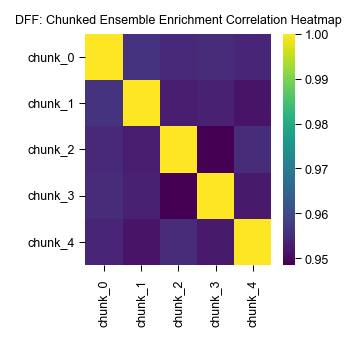

In [22]:
## pivot dff chunked ensembles activation and plot heatmap
enriched_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunked_ensembles)
fig, ax = plt.subplots(figsize=(2,2))
chunk_col = [c for c in enriched_by_chunk_dff.columns if 'chunk_' in c]
sns.heatmap(enriched_by_chunk_dff[chunk_col].corr(), vmax = 1, cmap='viridis')   
ax.set_title("DFF: Chunked Ensemble Enrichment Correlation Heatmap")


#### import raw shuffle data for DFF and spikes, to compare shuffle chunk similarity

In [23]:
spikes_shuffle_path = results_dir / Path(f"spikes_ensemble_detection_20-Nov-2025_5000 shuffles/shuffled_dfs_5000_per_subject")
print(f"Loading shuffles from {spikes_shuffle_path}")
all_shuffles_spikes =  read_shuffle_parquet_from_folder(spikes_shuffle_path) # Load all parquet files from that folder


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\spikes_ensemble_detection_20-Nov-2025_5000 shuffles\shuffled_dfs_5000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run


In [24]:
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes_spikes = transform_all_datasets(loaded_objects, datatype = 'raster', normalize = 'none')
all_chunk_ens_spikes = chunk_shuffles_by_subject(all_shuffles_spikes, raster_dataframes_spikes, chunk_size=1000)
enriched_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes)
enriched_by_chunk_spikes.head()


Processing raster of 10_3_HET_RS1: 163651520 bytes
 Dropping cells with 0 activity ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_36', 'cell_59', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processing raster of 10_3_HET_RS2: 131631360 bytes
 Dropping cells with 0 activity ['cell_13', 'cell_16', 'cell_38', 'cell_40', 'cell_41', 'cell_49', 'cell_57', 'cell_59', 'cell_65', 'cell_115', 'cell_120', 'cell_168']
Processing raster of 10_3_HET_RS3: 136645264 bytes
 Dropping cells with 0 activity ['cell_10', 'cell_22', 'cell_26', 'cell_38', 'cell_40', 'cell_45', 'cell_50', 'cell_81', 'cell_87', 'cell_101', 'cell_103', 'cell_134', 'cell_136', 'cell_143']
Processing raster of 13_3_HET_RS1: 245162240 bytes
 Dropping cells with 0 activity ['cell_4', 'cell_23', 'cell_28', 'cell_41', 'cell_91', 'cell_94', 'cell_97', 'cell_139']
Processing raster of 13_3_HET_RS2: 126035160 bytes
 Dropping cells with 0 activity ['cell_54', 'cell_65', 'cell_89', 'cell_97', 'cell_102', 'cell_126'

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False


In [25]:
def get_intercol_corrs(df: pd.DataFrame, stage_names: List[str], suffix1: str, suffix2: str) -> pd.DataFrame:
    """ Calculate correlations between columns with specified suffixes for each stage name.
    Inputs:
    df : DataFrame with columns to correlate
    stage_names : list of stage names to look for
    suffix1 : first suffix to append to stage names
    suffix2 : second suffix to append to stage names

    Returns: DataFrame of correlations"""
    
    correlations = {}
    for stage in stage_names:
        col1 = f"{stage}{suffix1}"
        col2 = f"{stage}{suffix2}"
        if col1 in df.columns and col2 in df.columns:
            corr_value = df[col1].corr(df[col2])
            correlations[stage] = corr_value
        else:
            print(f"Warning: Columns {col1} or {col2} not found in DataFrame.")
    
    corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
    return corr_df

      subject_name      task_stage     cell  chunk_0_dff  chunk_1_dff  \
35590  9_3_HET_RS2  Early_IA_Error  cell_70        False        False   

       chunk_2_dff  chunk_3_dff  chunk_4_dff  chunk_0_spikes  chunk_1_spikes  \
35590        False        False        False           False           False   

       chunk_2_spikes  chunk_3_spikes  chunk_4_spikes  
35590           False           False           False  


Text(0.5, 0.98, 'Python| Correlation between sets of 1000 shuffles each, for ensembles detected in zscored DFF & Spike rasters')

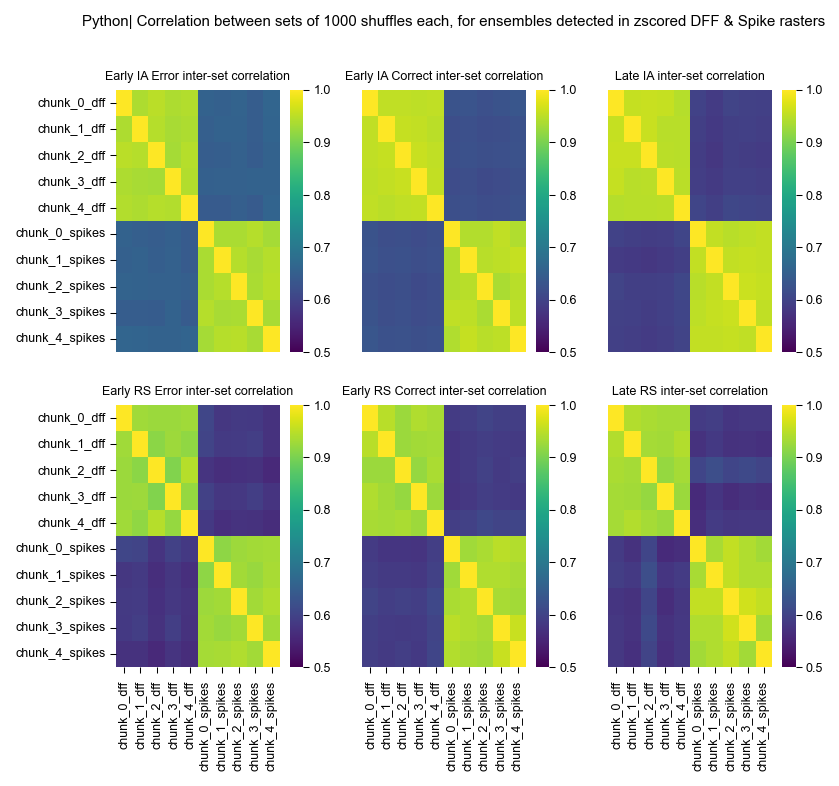

In [26]:
#merge enrich by chunk spikes and enriched by chunk dff
merged_enriched_chunks = pd.merge(enriched_by_chunk_dff, enriched_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
merge_chunk_col = [c for c in merged_enriched_chunks.columns if 'chunk_' in c]
print(merged_enriched_chunks.sample())

## make figure comparing correlation
fig,axes = plt.subplots(2,3, figsize=(6,5))
for s, stage in enumerate(stage_names):
    ax = axes.flatten()[s]
    stage_mask = merged_enriched_chunks['task_stage'] == stage
    stage_vals = merged_enriched_chunks.loc[stage_mask, merge_chunk_col].corr()
    sns.heatmap(stage_vals,vmin = 0.5, cmap='viridis', ax=ax)
    #drop x and y ticks if not on edges
    if s not in [3,0]:
        ax.set_yticks([])
    if s not in [3,4,5]:
        ax.set_xticks([])
    ax.set_title(f"{stage.replace("_", " ")} inter-set correlation")
fig.suptitle("Python| Correlation between sets of 1000 shuffles each, for ensembles detected in zscored DFF & Spike rasters")

Text(0.5, 0.98, 'Python| Correlation between sets of 1000 shuffles each, for ensembles detected in zscored DFF & Spike rasters')

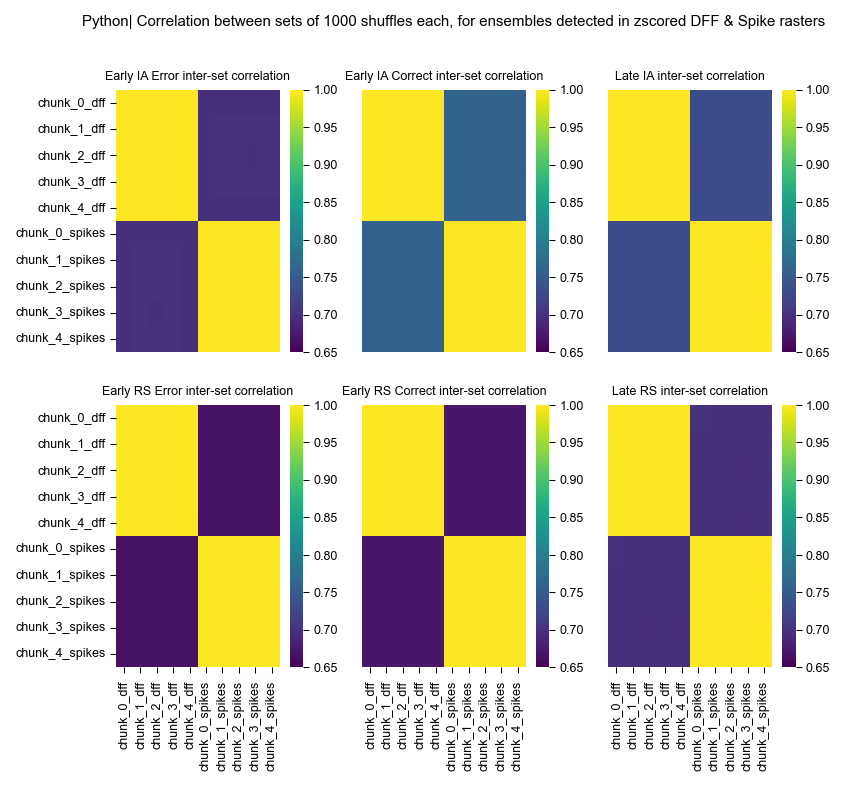

In [27]:
#use pvalue for corr 
pval_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes, pivot_values = 'percent_shuffle >= real')
pval_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunked_ensembles, pivot_values = 'percent_shuffle >= real')
merge_pval_chunks = pd.merge(pval_by_chunk_dff, pval_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
merge_chunk_col = [c for c in merged_enriched_chunks.columns if 'chunk_' in c]

fig,axes = plt.subplots(2,3, figsize=(6,5))
for s, stage in enumerate(stage_names):
    ax = axes.flatten()[s]
    stage_mask = merge_pval_chunks['task_stage'] == stage
    stage_vals = merge_pval_chunks.loc[stage_mask, merge_chunk_col].corr()

    sns.heatmap(stage_vals,cmap='viridis', vmin = 0.65, ax=ax)
    #drop x and y ticks if not on edges
    if s not in [3,0]:
        ax.set_yticks([])
    if s not in [3,4,5]:
        ax.set_xticks([])
    ax.set_title(f"{stage.replace("_", " ")} inter-set correlation")
fig.suptitle("Python| Correlation between sets of 1000 shuffles each, for ensembles detected in zscored DFF & Spike rasters")

In [28]:
merge_pval_chunks

,subject_name,task_stage,cell,chunk_0_dff,chunk_1_dff,chunk_2_dff,chunk_3_dff,chunk_4_dff,chunk_0_spikes,chunk_1_spikes,chunk_2_spikes,chunk_3_spikes,chunk_4_spikes
0,10_3_HET_RS1,Early_IA_Correct,cell_1,0.434,0.453,0.463,0.455,0.463,1.000,1.000,1.000,1.000,1.000
1,10_3_HET_RS1,Early_IA_Correct,cell_10,0.165,0.160,0.157,0.164,0.170,0.143,0.136,0.136,0.146,0.151
2,10_3_HET_RS1,Early_IA_Correct,cell_100,0.991,0.989,0.988,0.989,0.991,1.000,1.000,1.000,1.000,1.000
3,10_3_HET_RS1,Early_IA_Correct,cell_101,0.997,0.992,0.994,0.994,0.992,1.000,1.000,1.000,1.000,1.000
4,10_3_HET_RS1,Early_IA_Correct,cell_102,0.689,0.690,0.697,0.689,0.673,1.000,1.000,1.000,1.000,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37783,9_3_HET_RS3,truncated_post_outcome,cell_95,0.298,0.310,0.326,0.303,0.279,0.270,0.261,0.283,0.288,0.242
37784,9_3_HET_RS3,truncated_post_outcome,cell_96,0.009,0.006,0.013,0.015,0.008,0.009,0.007,0.013,0.013,0.012
37785,9_3_HET_RS3,truncated_post_outcome,cell_97,0.297,0.323,0.329,0.302,0.299,0.289,0.321,0.313,0.299,0.275
37786,9_3_HET_RS3,truncated_post_outcome,cell_98,1.000,1.000,1.000,1.000,0.997,0.998,0.995,0.999,1.000,0.997


In [29]:
merge_pval_chunks.groupby('subject_name')['cell'].nunique().sum()

5547

In [30]:
stage_vals

,chunk_0_dff,chunk_1_dff,chunk_2_dff,chunk_3_dff,chunk_4_dff,chunk_0_spikes,chunk_1_spikes,chunk_2_spikes,chunk_3_spikes,chunk_4_spikes
chunk_0_dff,1.000000,0.998572,0.998563,0.998556,0.998519,0.699533,0.699050,0.699047,0.698783,0.699051
chunk_1_dff,0.998572,1.000000,0.998535,0.998549,0.998534,0.699028,0.699116,0.698843,0.698567,0.698840
chunk_2_dff,0.998563,0.998535,1.000000,0.998550,0.998528,0.698263,0.698089,0.698381,0.697790,0.698094
chunk_3_dff,0.998556,0.998549,0.998550,1.000000,0.998527,0.698465,0.698269,0.698244,0.698270,0.698272
chunk_4_dff,0.998519,0.998534,0.998528,0.998527,1.000000,0.698063,0.697887,0.697895,0.697621,0.698213
chunk_0_spikes,0.699533,0.699028,0.698263,0.698465,0.698063,1.000000,0.999518,0.999495,0.999542,0.999483
chunk_1_spikes,0.699050,0.699116,0.698089,0.698269,0.697887,0.999518,1.000000,0.999526,0.999537,0.999512
chunk_2_spikes,0.699047,0.698843,0.698381,0.698244,0.697895,0.999495,0.999526,1.000000,0.999483,0.999509
chunk_3_spikes,0.698783,0.698567,0.697790,0.698270,0.697621,0.999542,0.999537,0.999483,1.000000,0.999510
chunk_4_spikes,0.699051,0.698840,0.698094,0.698272,0.698213,0.999483,0.999512,0.999509,0.999510,1.000000


In [31]:
# This is odd though- why would spikes and dff ensembles be so correlated on the identity? 

#### import both DFF & spike ensemble parquets


In [32]:
results_dir

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results')

In [33]:
# import DFF ensemble matrix 
dff_ens_path = results_dir / Path(r"dff_ensemble_detection_21-Nov-2025_5000 shuffles\dff_postoutcome_python_ensembles_5000_shuff_21-Nov-2025_.parquet")
dff_ens = pd.read_parquet(dff_ens_path)
if 'data_type' not in dff_ens.columns:
    dff_ens['data_type'] = 'dff'
print(dff_ens.info())
#get ensemble info from canon df
dff_ens.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40640 entries, 0 to 40639
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               40640 non-null  object 
 1   cell                     40640 non-null  object 
 2   percentile_95            40640 non-null  float64
 3   mean                     40640 non-null  float32
 4   enriched                 40640 non-null  bool   
 5   percent_shuffle >= real  40640 non-null  float64
 6   subject_name             40640 non-null  object 
 7   neuron_id                40640 non-null  object 
 8   date_made                40640 non-null  object 
 9   n_shuffles               40640 non-null  int64  
 10  data_type                40640 non-null  object 
dtypes: bool(1), float32(1), float64(2), int64(1), object(6)
memory usage: 3.0+ MB
None


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
40637,Late_IA,cell_215,0.001142,0.000316,False,0.9184,9_3_HET_RS3,9_3_HET_RS3-215,21-Nov-2025,5000,dff
40638,Late_RS,cell_215,0.001239,0.001194,False,0.0616,9_3_HET_RS3,9_3_HET_RS3-215,21-Nov-2025,5000,dff
40639,truncated_post_outcome,cell_215,0.000627,0.000333,False,0.9992,9_3_HET_RS3,9_3_HET_RS3-215,21-Nov-2025,5000,dff


In [34]:
data_types

['spikes', 'dff']

In [35]:
#import last spikes ensemble matrix for comparison
spikes_ens_path = results_dir / Path(r"spikes_ensemble_detection_20-Nov-2025_5000 shuffles\spikes_postoutcome_python_ensembles_5000_shuff_20-Nov-2025_.parquet")
spikes_ens = pd.read_parquet(spikes_ens_path)
if 'data_type' not in spikes_ens.columns:
    spikes_ens['data_type'] = 'spikes'
print(spikes_ens.info())
spikes_ens.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40640 entries, 0 to 40639
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               40640 non-null  object 
 1   cell                     40640 non-null  object 
 2   percentile_95            40640 non-null  float64
 3   mean                     40640 non-null  float64
 4   enriched                 40640 non-null  bool   
 5   percent_shuffle >= real  40640 non-null  float64
 6   subject_name             40640 non-null  object 
 7   neuron_id                40640 non-null  object 
 8   date_made                40640 non-null  object 
 9   n_shuffles               40640 non-null  int64  
 10  data_type                40640 non-null  object 
dtypes: bool(1), float64(3), int64(1), object(6)
memory usage: 3.1+ MB
None


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
40637,Late_IA,cell_215,0.022033,0.000000,False,1.0000,9_3_HET_RS3,9_3_HET_RS3-215,20-Nov-2025,5000,spikes
40638,Late_RS,cell_215,0.025000,0.017500,False,0.1106,9_3_HET_RS3,9_3_HET_RS3-215,20-Nov-2025,5000,spikes
40639,truncated_post_outcome,cell_215,0.007345,0.000332,False,0.9992,9_3_HET_RS3,9_3_HET_RS3-215,20-Nov-2025,5000,spikes


In [36]:
## pivot both enrichment vectors, then merge
spikes_ens_matrix = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
dff_ens_matrix = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
compare_spike_dff_ens = spikes_ens_matrix.merge(dff_ens_matrix, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_ens.info())
compare_spike_dff_ens.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5961 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5961 non-null   float64
 1   Early_IA_Error_spikes          4874 non-null   float64
 2   Early_RS_Correct_spikes        5961 non-null   float64
 3   Early_RS_Error_spikes          5961 non-null   float64
 4   Late_IA_spikes                 5961 non-null   float64
 5   Late_RS_spikes                 5961 non-null   float64
 6   truncated_post_outcome_spikes  5961 non-null   float64
 7   Early_IA_Correct_dff           5961 non-null   float64
 8   Early_IA_Error_dff             4874 non-null   float64
 9   Early_RS_Correct_dff           5961 non-null   float64
 10  Early_RS_Error_dff             5961 non-null   float64
 11  Late_IA_dff                    5961 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-10,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
df = compare_spike_dff_ens
correlations = {stage: df[stage+"_spikes"].corr(df[stage + '_dff']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.643866
Early_IA_Correct     0.617139
Late_IA              0.579809
Early_RS_Error       0.575530
Early_RS_Correct     0.587447
Late_RS              0.578939


In [38]:
## pivot both p-value matrices, then merge
spikes_ens_pval = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
dff_ens_pval = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
compare_spike_dff_p = spikes_ens_pval.merge(dff_ens_pval, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_p.info())
compare_spike_dff_p.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5961 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5961 non-null   float64
 1   Early_IA_Error_spikes          5961 non-null   float64
 2   Early_RS_Correct_spikes        5961 non-null   float64
 3   Early_RS_Error_spikes          5961 non-null   float64
 4   Late_IA_spikes                 5961 non-null   float64
 5   Late_RS_spikes                 5961 non-null   float64
 6   truncated_post_outcome_spikes  5961 non-null   float64
 7   Early_IA_Correct_dff           5961 non-null   float64
 8   Early_IA_Error_dff             5961 non-null   float64
 9   Early_RS_Correct_dff           5961 non-null   float64
 10  Early_RS_Error_dff             5961 non-null   float64
 11  Late_IA_dff                    5961 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,1.0000,0.0008,1.0,1.0000,1.0000,1.0,0.1388,0.4536,0.0040,0.2276,0.6784,0.4888,0.7558,0.0696
10_3_HET_RS1-10,0.1424,0.0046,1.0,0.0972,0.2986,1.0,0.0002,0.1632,0.0152,0.8634,0.0508,0.3794,0.9782,0.0008
10_3_HET_RS1-100,1.0000,1.0000,1.0,1.0000,1.0000,1.0,0.9936,0.9896,0.8938,0.9890,0.8388,0.9968,0.9750,0.9978


In [39]:
corr_df = get_intercol_corrs(compare_spike_dff_p, stage_names, suffix1="_spikes", suffix2="_dff")
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.779182
Early_IA_Correct     0.745727
Late_IA              0.721740
Early_RS_Error       0.654836
Early_RS_Correct     0.662784
Late_RS              0.682847


#### Threshold time-series df to remove 0 

In [40]:
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import annotate_csv, run_min_max_norm_on_timeseries


def extract_trial_windows(df, pre_frames=60, post_frames=300) -> pd.DataFrame:
    """Extract last N pre-outcome and M post-outcome frames for each trial, padded to consistent length."""
    
    # Validation: Check monotonicity within each trial
    grouped = df.groupby(['subject_name', 'session', 'trial_num'])
    
    for trial_id, trial_data in grouped:
        frame_nums = trial_data.index.str.extract(r'frame_(\d+)')[0].astype(int)
        if not frame_nums.is_monotonic_increasing:
            raise ValueError(f"Non-monotonic indices in trial {trial_id}")
    
    full_frame_range = list(range(-pre_frames, 0)) + list(range(1, post_frames + 1))
    trial_windows = []
    
    for trial_id, trial_data in grouped:
        pre = trial_data[trial_data['trial_section'] == 'pre_outcome'].tail(pre_frames)
        post = trial_data[trial_data['trial_section'] == 'post_outcome'].head(post_frames)
        
        # Create frame indices
        n_pre = len(pre)
        n_post = len(post)
        pre_indices = list(range(-n_pre, 0))
        post_indices = list(range(1, n_post + 1))
        
        # Add indices before concatenating (avoids fragmentation)
        pre_with_idx = pre.assign(trial_window_frame=pre_indices)
        post_with_idx = post.assign(trial_window_frame=post_indices)
        
        # Concatenate
        combined = pd.concat([pre_with_idx, post_with_idx], ignore_index=True)
        
        # Reindex to full range - automatically pads with NaN for truncated trials
        combined = combined.set_index('trial_window_frame').reindex(full_frame_range).reset_index()
        
        # Forward-fill metadata (they're constant within trial)
        metadata = ['subject_name', 'session', 'trial_num', 'geno', 'task_stage', 'normalized', 'datatype']
        for col in [c for c in metadata if c in combined.columns]:
            combined[col] = combined[col].ffill()
        
        trial_windows.append(combined)
    
    return pd.concat(trial_windows, ignore_index=True)

def pivot_trial_windows(windowed_df, 
                        samples_col = 'trial_window_frame',
                        frame_prefix:str = 'f_',
                        new_cell_col_name:str = 'cell') -> pd.DataFrame:
    """  Pivot so each row is one cell from one trial. Columns: metadata + frame_1, frame_2, ..., frame_360 """
    
    cell_cols = [col for col in windowed_df.columns if col.startswith('cell_')]
    # Melt: convert cell columns to rows
    melted = windowed_df.melt(id_vars=['trial_num', samples_col], value_vars=cell_cols, var_name=new_cell_col_name, value_name='activity')
    # Pivot: convert frames to columns
    pivoted = melted.pivot(index=['trial_num', new_cell_col_name],columns=samples_col,values='activity')
    #detect if frame is negative or positive and rename columns # Rename columns: negative = -f_N (pre), positive = f_N (post)
    new_columns = []
    for frame in pivoted.columns:
        if frame < 0:
            new_columns.append(f'-f_{abs(frame)}')  # -60 -> -f_60, -1 -> -f_1
        else:
            new_columns.append(f'f_{frame}')  # 1 -> f_1, 300 -> f_300
    # rename columns
    pivoted.columns = new_columns
    pivoted = pivoted.reset_index()
    
    # Add back metadata
    metadata_cols_kept = ['trial_num', 'subject_name', 'session', 'geno', 'task_stage', 'normalized', 'datatype']
    metadata_cols_kept = [col for col in metadata_cols_kept if col in windowed_df.columns]
    metadata_map = windowed_df[metadata_cols_kept].drop_duplicates()
    pivoted = pivoted.merge(metadata_map, on='trial_num', how='left')
        
    # Value spot check
    sample_trial = pivoted['trial_num'].iloc[0]
    sample_cell = cell_cols[0]
    frame_cols = [col for col in pivoted.columns if col.startswith(('f_', '-f_'))]
    
    original = windowed_df[windowed_df['trial_num'] == sample_trial][sample_cell].values
    pivoted_vals = pivoted[(pivoted['trial_num'] == sample_trial) & (pivoted[new_cell_col_name] == sample_cell)][frame_cols].values.flatten()
    
    # TESTS
    assert not pivoted[['trial_num', new_cell_col_name]].duplicated().any(), "Found duplicate trial-cell combinations!"
    assert np.allclose(original, pivoted_vals, equal_nan=True), "Data corruption detected!"
    
    return pivoted

<Figure size 960x720 with 0 Axes>

In [41]:
#for concordance with previous code, need to label the stage col as 'task_stage_vec
stage_col = 'task_phase_vec'

## main time-series df creation function for datasets processed in python
def create_subject_trial_tseries_df(input_df: pd.DataFrame,
                                    ens_matrix: pd.DataFrame,
                                    window_to_bin = 5,
                                    n_sec_to_rotate = 0,
                                    cell_col = 'cell',
                                    cols_to_drop= None,
                                    stage_col = 'task_phase_vec',
                                    stage_names = None,
                                    ) -> pd.DataFrame:
    """ Create trial-cell time-series DataFrame for one subject, with ensemble info joined. For python native created dfs
    Inputs:
    raster_df : DataFrame with one row per frame
    """
    #default args
    if cols_to_drop is None:
        cols_to_drop = ['threshold_with_shuffle','peak_dff_threshold_percentile','drop_low_value_peak_events','cutoff_filter','peak_event_cutoff_percentile']   
    if stage_names is None:
        stage_names = ['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct','Late_RS']
        
    # extract trial windows from df, removing excess frames
    trim_df = extract_trial_windows(input_df)
    #reshape df into long format: one row per trial-cell, columns = time-series frames
    outcome_post = pivot_trial_windows(trim_df).rename(columns={'task_stage': stage_col})
    outcome_post['neuron_id'] = outcome_post['subject_name'] + '-' + outcome_post[cell_col].str.replace('cell_','') 
    outcome_post =outcome_post.drop([x for x in cols_to_drop if x in outcome_post], axis = 1).dropna(subset = [stage_col])
    annotate_csv(outcome_post, 'subject_name')

    ## begin preprocess- bin and rotate timeseries 
    outcome_post = bin_rotate_timeseries(outcome_post, window_size = window_to_bin, rotate_by = n_sec_to_rotate)
    outcome_post = outcome_post.join(ens_matrix, on='neuron_id', how='left', rsuffix='_ens') #join dff timeseries with ensemble info
    #drop time-series not belonging to any task stage , aka the 0 task stage 
    outcome_post['any_enrichment']= outcome_post[stage_names].sum(axis = 1)
    outcome_post = outcome_post[outcome_post[stage_col].isin(stage_names)]
    trial_tseries_df_raw = add_enriched_in_curr_phase_col(outcome_post, stage_col)
    return trial_tseries_df_raw



def normalize_tseries_df(trial_tseries_df_raw: pd.DataFrame,
                          n_end_timebins_to_drop = 0,
                          n_start_timebins_to_drop = 8,
                          name_col: str = 'subject_name',
                          neuron_id_col: str = 'neuron_id',
                          ) -> pd.DataFrame:
    """ Normalize trial time-series DataFrame based on normalization type.
    Inputs:
    trial_tseries_df_raw : DataFrame with raw time-series data
    hyper_param_dict : dictionary of hyperparameters
    outcome_post : DataFrame with outcome post data

    Returns: Normalized trial time-series DataFrame
    """
    #get normalization info for curr df
    normed = trial_tseries_df_raw['normalized'].unique()[0]
    if normed == 'none':
        use_min_max_norm = True 
    else:
        use_min_max_norm = False
    print(f" Data Normalization type: {normed} | Applying min-max norm? {use_min_max_norm} ")

    numeric_col = get_numeric_cols_timeseries(trial_tseries_df_raw, " to ") 
    trial_tseries_df_norm = run_min_max_norm_on_timeseries(use_min_max_norm, trial_tseries_df_raw, [name_col, neuron_id_col], numeric_col, 'max_trial_val') #min_max_norm = True

    #get mean of each trial
    trial_tseries_df_norm['mean_rate'] =trial_tseries_df_norm[[c for c in numeric_col if '-' not in c]].mean(axis = 1) #mean rate is post outcome only
    trial_tseries_df_norm['active_in_trial'] =trial_tseries_df_norm['mean_rate']>0

    #OPTIONAL- drop N bins from start and M bins from end of time-series
    trial_tseries_df_norm = drop_end_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_end_timebins_to_drop = n_end_timebins_to_drop )
    trial_tseries_df_norm = drop_start_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_start_timebins_to_drop =n_start_timebins_to_drop)
    return trial_tseries_df_norm

def normalize_all_subject_tseries_dfs(raster_base_dfs: Dict[str, pd.DataFrame],
                                      n_end_timebins_to_drop = 0,
                                      n_start_timebins_to_drop = 8,
                                      name_col: str = 'subject_name',
                                      neuron_id_col: str = 'neuron_id',
                                      ) -> pd.DataFrame:
    """ Normalize all subject trial time-series DataFrames.
    Inputs:     raster_base_dfs : Dict of subject_name to raw full recording matrix DataFrame
    optional settings for time-series normalization that equal defaults, so left un input

    Returns: concat. dataframe of subject_name to normalized trial time-series DataFrame
    """

    raster_timeseries =[]
    for name, raster_df in raster_base_dfs.items():
        print(f" Reshaping tseries of {name}: {raster_df.shape}")    
        subj_trial_tseries_df_raw= create_subject_trial_tseries_df(raster_df, dff_ens_matrix)
        subj_trial_tseries_df_norm= normalize_tseries_df(subj_trial_tseries_df_raw)
        raster_timeseries.append(subj_trial_tseries_df_norm)
    trial_tseries_df_norm = pd.concat(raster_timeseries)
    return trial_tseries_df_norm

In [42]:
trial_tseries_df_norm = normalize_all_subject_tseries_dfs(raster_dataframes)
# get mean time-sereis value
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")  #update post drop
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['subject_name', 'neuron_id','geno_day', stage_col], numeric_col) 
unit_mean_tseries


 Reshaping tseries of 10_3_HET_RS1: (135487, 147)
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 60
rem_frames: 0
 Moving numeric coluns by 0 bins
 Data Normalization type: baseline_zscore | Applying min-max norm? False 
Dropping 0 bins from end: []
Dropping 8 bins from start: Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s',
       '-1.5s to -1.25s', '-1.25s to -1.0s'],
      dtype='object')
 Reshaping tseries of 10_3_HET_RS2: (85240, 179)
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 60
rem_frames: 0
 Moving numeric coluns by 0 bins
 Data Normalization type: baseline_zscore | Applying min-max norm? False 
Dropping 0 bins from end: []
Dropping 8 bins from start: Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s',
       '-1.5s to -1.25s', '-1.25s to -1.0s'],
      dtype='object')
 Reshaping 

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\preprocess_data.py:235: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  cell_avg_stage_tseries['max_val_tbin']= cell_avg_stage_tseries.loc[:,[c for c in cell_avg_stage_tseries.columns if "to" in c]].idxmax(axis = 1)


,subject_name,neuron_id,geno_day,task_phase_vec,-1.0s to -0.75s,-0.75s to -0.5s,-0.5s to -0.25s,-0.25s to -0.0s,0.0s to 0.25s,0.25s to 0.5s,...,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome,any_enrichment,enriched_in_phase,mean_rate,active_in_trial,max_val,max_val_tbin
0,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Correct,0.923755,0.727587,0.606845,0.573206,0.475119,0.384726,...,0.0,0.0,0.0,0.0,1.0,False,-0.153341,False,0.923755,-1.0s to -0.75s
1,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Error,-0.213771,-0.226000,-0.233417,-0.233417,-0.233417,-0.233417,...,0.0,0.0,0.0,0.0,1.0,True,15.303195,True,23.894199,12.5s to 12.75s
2,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Correct,2.363398,2.305951,2.039729,1.944668,1.808385,1.696944,...,0.0,0.0,0.0,0.0,1.0,False,0.224163,True,2.363398,-1.0s to -0.75s
3,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Error,-0.233417,-0.233417,-0.233417,-0.233417,-0.233417,-0.233417,...,0.0,0.0,0.0,0.0,1.0,False,-0.232603,False,-0.211073,3.5s to 3.75s
4,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Late_IA,0.509771,0.437228,0.381712,0.481910,0.498577,0.335376,...,0.0,0.0,0.0,0.0,1.0,False,-0.126884,False,0.509771,-1.0s to -0.75s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33732,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_IA_Error,-0.133801,0.041956,-0.188911,-0.464621,-0.442928,-0.465726,...,0.0,0.0,0.0,0.0,0.0,False,-0.424521,False,0.041956,-0.75s to -0.5s
33733,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Correct,-0.404872,-0.294553,-0.345455,-0.312699,-0.392900,-0.414664,...,0.0,0.0,0.0,0.0,0.0,False,-0.315641,False,0.143792,8.0s to 8.25s
33734,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Error,0.690022,0.156748,-0.050995,-0.143176,-0.088702,0.254124,...,0.0,0.0,0.0,0.0,0.0,False,0.015789,True,0.898590,3.0s to 3.25s
33735,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Late_IA,0.139083,-0.057148,-0.114513,-0.320696,-0.095593,-0.338380,...,0.0,0.0,0.0,0.0,0.0,False,-0.011895,True,0.943868,3.25s to 3.5s


In [43]:
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['neuron_id'].nunique()
print(n_total_units)
print(n_total_units.sum())
#save filename with data type and date info
save_name = results_dir / Path(f"trial_timeseries_{data_type_used}_{datetime.now().strftime("%Y-%m-%d %H")}.parquet")
trial_tseries_df_norm.to_parquet(save_name)


geno_day
Het CLNZ        1094
Het VEH         1094
Het postCLNZ    1177
WT CLNZ         1246
WT VEH          1193
Name: neuron_id, dtype: int64
5804


#### new- UMAP on enrichment matrices

In [44]:
!pip install umap-learn

In [45]:
# UMAP analysis on ensemble matrices
import umap
from sns_plotting_config import * #import dicts containing default plot params

# Determine first active stage for each neuron
def get_first_active_stage(row, stage_order,  non_enriched_label = 'Never'):
    """Find the first stage where neuron is enriched (value = 1)"""
    for stage in stage_order:
        if stage in row.index and row[stage] == 1:
            return stage
    return non_enriched_label

def run_umap_with_stage_labels(ensemble_matrix, stage_names, enrichment_col = None,
                                n_neighbors=15, min_dist=0.1,  
                                metric='hamming', random_state=42):
    """
    Run UMAP on ensemble matrix and label neurons by first active stage.
    
    Parameters:
    -----------
    ensemble_matrix : pd.DataFrame
        Binary ensemble membership matrix (neurons x task_stages)
    stage_names : list
        Chronological order of task stages
    n_neighbors : int
        UMAP n_neighbors parameter (default: 15)
    min_dist : float
        UMAP min_dist parameter (default: 0.1)
    metric : str
        Distance metric for UMAP (default: 'hamming')
    random_state : int
        Random seed for reproducibility (default: 42)
    
    Returns:
    --------
    results_df : pd.DataFrame
        DataFrame with columns: UMAP1, UMAP2, First_Active_Stage
    umap_model : umap.UMAP
        Fitted UMAP model (useful for transforming new data)
    """
    import umap
    import pandas as pd
    
    # Get complete data (drop rows with any NaN)
    complete_data = ensemble_matrix.dropna()
    
    print(f"Base shape: {ensemble_matrix.shape}")
    print(f"Complete cases: {complete_data.shape}")
    
    # Run UMAP
    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state)
    embedding = umap_model.fit_transform(complete_data)
    
    # Prepare results dataframe
    results_df = pd.DataFrame({
        'UMAP1': embedding[:, 0], 'UMAP2': embedding[:, 1],
        })
    
    # Preserve neuron IDs from index
    results_df.index = complete_data.index
    return results_df, umap_model


In [46]:
#set umap params
value_to_project = 'mean'
metric = 'cosine'

# Run UMAP on both spike and DFF ensemble matrices
spike_umap_input = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)
spikes_df, umap_spikes_model = run_umap_with_stage_labels( spike_umap_input, 
    stage_names, n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)

dff_umap_input = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)
dff_df, umap_dff_model = run_umap_with_stage_labels(dff_umap_input,
      stage_names, n_neighbors=15, min_dist=0.2, metric=metric, random_state=42)

#join umap dfs with ensemble enrichment info
spike_cell_enrich = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
spikes_df = spikes_df.merge(spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)
dff_cell_enrich = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
dff_df = dff_df.merge(dff_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)
# spikes_df = spikes_df.merge(spikes_ens[['neuron_id', 'task_stage', 'enriched']], left_index=True, right_on='neuron_id')
# dff_df = dff_df.merge(dff_ens[['neuron_id', 'enriched']], left_index=True, right_on='neuron_id')

Base shape: (5961, 6)
Complete cases: (5961, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Base shape: (5961, 6)
Complete cases: (5961, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [47]:
spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False)

task_stage,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome
neuron_id,,,,,,,
10_3_HET_RS1-1,0.000000,0.686667,0.000000,0.000000,0.000000,0.0,0.028814
10_3_HET_RS1-10,0.056667,0.476667,0.000000,0.096667,0.020000,0.0,0.067075
10_3_HET_RS1-100,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.009842
10_3_HET_RS1-101,0.000000,0.0,0.000000,0.000000,0.022667,0.0,0.032055
10_3_HET_RS1-102,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.009842
...,...,...,...,...,...,...,...
9_3_HET_RS3-95,0.000000,0.026667,0.000000,0.000000,0.000000,0.0,0.013717
9_3_HET_RS3-96,0.000000,0.181667,0.093333,0.000000,0.000000,0.0,0.050044
9_3_HET_RS3-97,0.033333,0.123333,0.000000,0.000000,0.000000,0.0,0.011504


In [48]:
dff_df

,UMAP1,UMAP2,first_active_stage
neuron_id,,,
10_3_HET_RS1-1,12.622513,10.524050,Early_IA_Error
10_3_HET_RS1-10,11.150599,7.630769,Early_IA_Error
10_3_HET_RS1-100,5.013901,-0.784930,Never
10_3_HET_RS1-101,1.982271,1.774831,Never
10_3_HET_RS1-102,5.859055,0.542735,Never
...,...,...,...
9_3_HET_RS3-95,7.824842,6.792192,Never
9_3_HET_RS3-96,9.832567,4.483198,Never
9_3_HET_RS3-97,10.235147,10.320923,Early_IA_Error


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use 

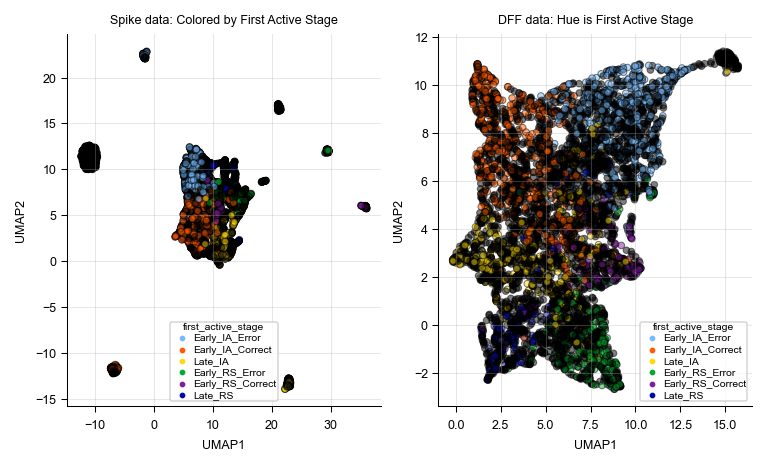

In [49]:
## PLOTTING- note that paper tSNE is projection of mean activity in stage, colored by ensemble identity
fig, axes = plt.subplots(1, 2, figsize=(5, 3), layout='constrained')
palette = [stage_palette_dict[x] for x in stage_names] + ['lightgray']
hue_col = 'first_active_stage'

# Spikes
sns.scatterplot(ax=axes[0], data=spikes_df, x='UMAP1', y='UMAP2', hue=hue_col,     palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',linewidth=0.5, legend='full')
axes[0].set_title(f'Spike data: Colored by First Active Stage')
axes[0].grid(True, alpha=0.3)

# DFF
sns.scatterplot(ax=axes[1], data=dff_df, x='UMAP1', y='UMAP2', hue=hue_col, palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',  linewidth=0.5, legend='full')
axes[1].set_title(f'DFF data: Hue is First Active Stage')
axes[1].grid(True, alpha=0.3)

#Final check- save manifest of config

In [51]:
subjects= unit_mean_tseries['subject_name'].unique().tolist()
enrichment_output_path = "None"
timeseries_output_path= "None"

In [52]:
# Cell: Save run manifest
runtime = time.time() - START_TIME

manifest = create_run_manifest(
    config=config,
    output_dir=run_output_dir,
    run_id=RUN_ID,
    inputs={
        'source_data': str(config['data']['source_dataset_location']),
        'n_subjects': len(subjects),
    },
    outputs={
        'shuffle_parquets': str(run_output_dir),
        'n_files': len(list(run_output_dir.glob('*.parquet'))),
        'enrichment_results': str(enrichment_output_path),
        'timeseries_results': str(timeseries_output_path),
    },
    performance={
        'runtime_seconds': int(runtime),
        'runtime_human': f"{runtime/3600:.1f} hours",
        'n_cores_used': config['shuffles']['n_cores'],
    },
    status={
        'success': True,
        'errors': [],
        'warnings': [],
    }
)

# Update central run log
run_db = update_run_database(manifest, db_path=results_dir / 'run_log.csv')

print(f"\n{'='*60}")
print(f"Run complete: {RUN_ID}")
print(f"Runtime: {runtime/3600:.1f} hours")
print(f"Outputs: {run_output_dir}")
print(f"Manifest: {run_output_dir / f'run_manifest_{RUN_ID}.yaml'}")
print(f"{'='*60}")

[OK] Manifest saved to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251128_135545\run_manifest_20251128_135545.yaml
[OK] Run database updated: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\run_log.csv
     Total runs recorded: 1

Run complete: 20251128_135545
Runtime: 0.2 hours
Outputs: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251128_135545
Manifest: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251128_135545\run_manifest_20251128_135545.yaml
